In [1]:
from facial_landmarks.facial_processor import FacialLandmarkProcessor, ProcessingConfig
import cv2
import matplotlib.pyplot as plt

In [2]:
# Configure model properties and create facial landmark model
config = ProcessingConfig(
    enable_face_detection = True,
    draw_face_boxes = True,
    draw_landmarks = False,
    draw_face_keypoints = False,
    draw_detailed_landmarks = False,
    landmark_tracking_confidence = 0.99,
    face_model_selection=1
)

model = FacialLandmarkProcessor(config)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


W0000 00:00:1773915892.763744   39776 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773915892.770997   39764 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773915892.781638   39776 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Found 1 face.
Found 478 landmarks.
Processing time: 68.2ms


W0000 00:00:1773915893.873199   39774 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


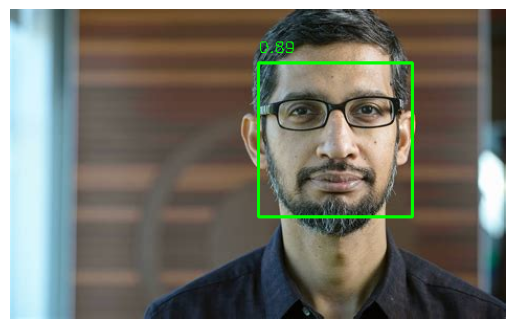

In [ ]:
# Load image and process
img = cv2.imread("../images/google_ceo.jpg")
result = model.process_image(img)

# Access results
print(f"Found {len(result.faces)} face{'s' if len(result.faces) != 1 else ''}.")
if not result.landmarks:
    print(f"No landmarks detected.")
else:
    print(f"Found {len(result.landmarks[0].landmarks)} landmarks.")
print(f"Processing time: {result.processing_time*1000:.1f}ms")

# Show results
plt.imshow(cv2.cvtColor(result.processed_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

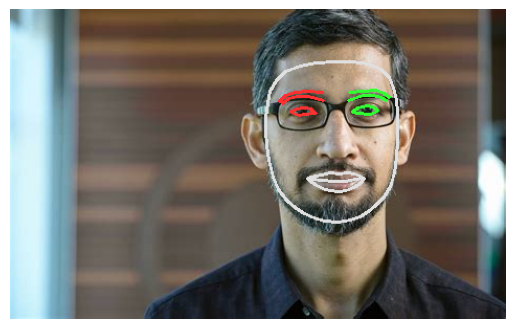

In [4]:
# Show contours of face
annotated = model.landmark_detector.draw_landmarks(img, result.landmarks)

# Show results
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

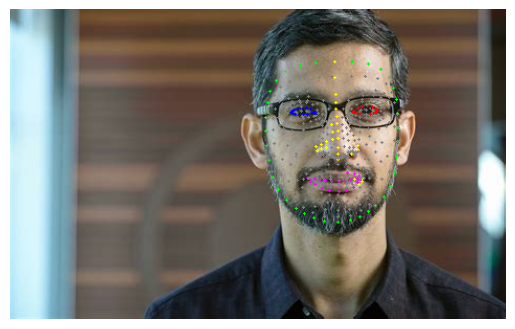

In [5]:
# Show detailed landmarks
annotated = model.landmark_detector.draw_landmarks(img, result.landmarks, draw_connections=False)

# Show results
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Found 1 face.
No landmarks detected.
Processing time: 10.7ms


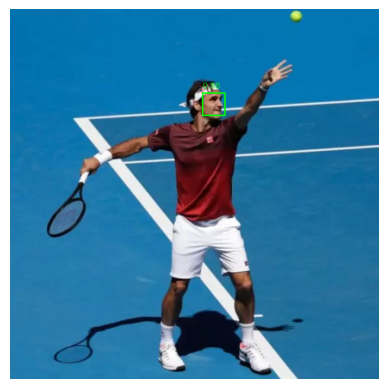

In [ ]:
# Working with a slightly harder image, we can see that the model still detects the face, but doesn't find any landmarks
img = cv2.imread("../images/sample.jpg")
result = model.process_image(img)

# Access results
print(f"Found {len(result.faces)} face{'s' if len(result.faces) != 1 else ''}.")
if not result.landmarks:
    print(f"No landmarks detected.")
else:
    print(f"Found {len(result.landmarks[0].landmarks)} landmarks.")
print(f"Processing time: {result.processing_time*1000:.1f}ms")

# Show results
plt.imshow(cv2.cvtColor(result.processed_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Found 4 faces.
No landmarks detected.
Processing time: 7.4ms


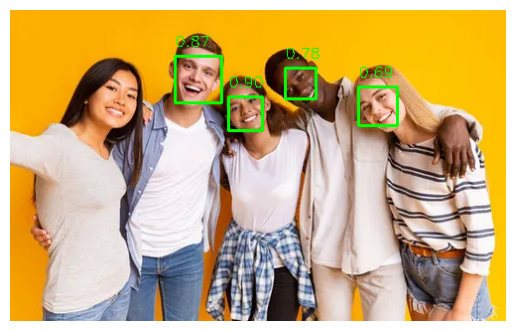

In [ ]:
# Now with an image that contains multiple faces...
img = cv2.imread("../images/group_photo.webp")
result = model.process_image(img)

# Access results
print(f"Found {len(result.faces)} face{'s' if len(result.faces) != 1 else ''}.")
if not result.landmarks:
    print(f"No landmarks detected.")
else:
    print(f"Found {len(result.landmarks[0].landmarks)} landmarks.")
print(f"Processing time: {result.processing_time*1000:.1f}ms")

# Show results
plt.imshow(cv2.cvtColor(result.processed_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Found 1 face.
No landmarks detected.
Processing time: 7.9ms


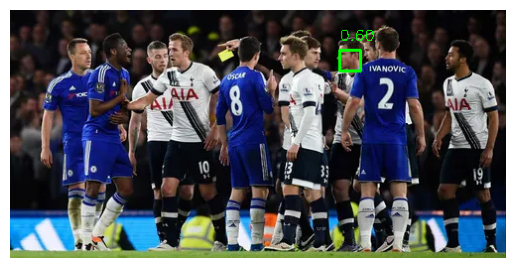

In [ ]:
# Now with an image that contains multiple faces...
img = cv2.imread("../images/epl.webp")
result = model.process_image(img)

# Access results
print(f"Found {len(result.faces)} face{'s' if len(result.faces) != 1 else ''}.")
if not result.landmarks:
    print(f"No landmarks detected.")
else:
    print(f"Found {len(result.landmarks[0].landmarks)} landmarks.")
print(f"Processing time: {result.processing_time*1000:.1f}ms")

# Show results
plt.imshow(cv2.cvtColor(result.processed_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()